# Cleaning the Baier–Bergstrand Trade Agreement Data

This notebook builds the African country–year trade-agreement panel described in
[`docs/developing-country-trade-productivity.md`](../docs/developing-country-trade-productivity.md),
§5–§6 (data inventory and proposed methodology). It takes the raw bilateral
country-pair–year Economic Integration Agreement (EIA) database from Baier &
Bergstrand and turns it into a clean **African country–year panel** carrying the
treatment variables the methodology document specifies, ready to be merged with the
GGDC sectoral productivity data in a later notebook.

**What this notebook does, in order:**

1. Load the raw `Data Sheet` from the Baier–Bergstrand workbook (`data/baier-bergstrand/`).
2. Reshape from wide (one column per year, 1950–2017) to long (one row per country-pair–year).
3. Restrict to pairs between the project's 24 African countries and a fixed-vintage list
   of "Northern" (advanced) economies.
4. Investigate and correctly handle an important structural feature of the raw data:
   non-reciprocal preference codes are *directional*, not duplicated across both listed
   directions of a pair.
5. Collapse to a single African country–year panel, taking the deepest (maximum) level
   of integration across all Northern partners in each year.
6. Construct the treatment variables from §6.2 of the methodology document —
   `reciprocal` (the primary treatment), plus `depth_score`, `fta_or_deeper`,
   `nonreciprocal_only`, and `agreement_type` (reserved for the §6.4.D heterogeneity
   analysis).
7. Run the two empirical diagnostics §6.2/§6.6 call for *before* committing to a
   single staggered-DiD estimator: an absorbing-treatment (no-reversion) check, and a
   staggered-vs-bunched timing check.
8. Save the cleaned panel(s) to `data/processed/`.

**A note on the file paths below:** they assume this notebook is run from a
`notebooks/` folder at the repo root, with the Baier–Bergstrand workbook at
`../data/baier-bergstrand/EIA_Database_2021-07-31.xlsm` — i.e., run it as checked
into the repo, unmoved.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

In [2]:
REPO_ROOT = Path("..")
BB_XLSM = REPO_ROOT / "data" / "baier-bergstrand" / "EIA_Database_2021-07-31.xlsm"
OUT_DIR = REPO_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

BB_XLSM

WindowsPath('../data/baier-bergstrand/EIA_Database_2021-07-31.xlsm')

## 2. Load the raw `Data Sheet`

The workbook's `Data Sheet` is a country-pair–year panel: 10 identifier columns
(exporter/importer names, IDs, ISO3 codes, pair IDs) followed by one column per year,
1950–2017. It is read directly with `openpyxl` — no macros are executed (this project
uses the `(without links)` workbook release; see `data/baier-bergstrand/README.md` for
why).

In [3]:
raw = pd.read_excel(BB_XLSM, sheet_name="Data Sheet", engine="openpyxl")

id_cols = ["Exporter", "IDEX", "ISOEX", "Importer", "IDIM", "ISOIM",
           "IDPAIR (Relative)", "IDPAIR", "Countries", "Sort Pair"]
year_cols = [c for c in raw.columns if isinstance(c, int) and 1950 <= c <= 2017]

raw = raw[id_cols + year_cols].dropna(subset=["Exporter"]).reset_index(drop=True)

print(f"{raw.shape[0]:,} country-pair rows x {len(year_cols)} years ({year_cols[0]}-{year_cols[-1]})")
raw.head(3)

37,830 country-pair rows x 68 years (1950-2017)


,Exporter,IDEX,ISOEX,Importer,IDIM,ISOIM,IDPAIR (Relative),IDPAIR,Countries,Sort Pair,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,Afghanistan,1,AFG,Albania,2,ALB,10021001,10011002,AlbaniaAfghanistan,2,...,0,0,0,0,0,0,0,0,0,0
1,Afghanistan,1,AFG,Algeria,3,DZA,10031001,10011003,AlgeriaAfghanistan,2,...,0,0,0,0,0,0,0,0,0,0
2,Afghanistan,1,AFG,Angola,4,AGO,10041001,10011004,AngolaAfghanistan,2,...,0,0,0,0,0,0,0,0,0,0


## 3. Reshape to long format and clean the level column

Each year cell holds either an integration-depth code (0–6, see the level table in
§6.2 of the methodology doc) or the string `"NoCty"`, meaning one side of the pair did
not yet exist as a recognized country that year. These need to become a numeric
`level` column plus a separate `not_yet_country` flag — collapsing `NoCty` straight to
0 would silently misrepresent "the country didn't exist" as "the country existed and
had no agreement," which is a real and different thing.

In [4]:
long = raw.melt(
    id_vars=["ISOEX", "ISOIM"],
    value_vars=year_cols,
    var_name="year",
    value_name="level_raw",
)

long["not_yet_country"] = long["level_raw"].astype(str).eq("NoCty")
long["level"] = pd.to_numeric(long["level_raw"], errors="coerce")

print(f"{len(long):,} long rows")
long["level"].value_counts(dropna=False).sort_index()

2,572,440 long rows


level
0.0    1747136
1.0     156292
2.0      53984
3.0      46717
4.0      12210
5.0      10466
6.0       5364
NaN     540271
Name: count, dtype: int64

## 4. Country classifications

Two fixed-vintage lists, so a country's classification does not change as it develops
over the sample window (per §5.2 of the methodology doc):

- **African sample**: the 24 African countries already present in the project's GGDC
  10-Sector productivity data (§5.1 of the methodology doc).
- **Northern partners**: the IMF World Economic Outlook "Advanced Economies"
  classification — used as-is rather than re-derived, since it's a standard,
  citable, fixed list rather than a bespoke one.

Both are keyed by ISO3 code, matched directly against Baier–Bergstrand's own `ISOEX`
/ `ISOIM` columns — no name-matching heuristics needed.

In [5]:
AFRICAN = {
    "DZA": "Algeria", "AGO": "Angola", "BWA": "Botswana", "BFA": "Burkina Faso",
    "CMR": "Cameroon", "EGY": "Egypt", "SWZ": "Eswatini", "ETH": "Ethiopia",
    "GHA": "Ghana", "KEN": "Kenya", "LSO": "Lesotho", "MWI": "Malawi",
    "MUS": "Mauritius", "MAR": "Morocco", "MOZ": "Mozambique", "NAM": "Namibia",
    "NGA": "Nigeria", "RWA": "Rwanda", "SEN": "Senegal", "SLE": "Sierra Leone",
    "ZAF": "South Africa", "TZA": "Tanzania", "UGA": "Uganda", "ZMB": "Zambia",
}

# IMF WEO "Advanced Economies" classification (fixed vintage).
NORTHERN = {
    "AUS": "Australia", "AUT": "Austria", "BEL": "Belgium", "CAN": "Canada",
    "CYP": "Cyprus", "CZE": "Czech Republic", "DNK": "Denmark", "EST": "Estonia",
    "FIN": "Finland", "FRA": "France", "DEU": "Germany", "GRC": "Greece",
    "HKG": "Hong Kong SAR", "ISL": "Iceland", "IRL": "Ireland", "ISR": "Israel",
    "ITA": "Italy", "JPN": "Japan", "KOR": "Republic of Korea", "LVA": "Latvia",
    "LTU": "Lithuania", "LUX": "Luxembourg", "MLT": "Malta", "NLD": "Netherlands",
    "NZL": "New Zealand", "NOR": "Norway", "PRT": "Portugal", "SGP": "Singapore",
    "SVK": "Slovakia", "SVN": "Slovenia", "ESP": "Spain", "SWE": "Sweden",
    "CHE": "Switzerland", "TWN": "Taiwan", "GBR": "United Kingdom", "USA": "United States",
}

all_iso = set(long["ISOEX"]).union(long["ISOIM"])
missing = [c for c in {**AFRICAN, **NORTHERN} if c not in all_iso]

print(f"{len(AFRICAN)} African countries, {len(NORTHERN)} Northern partners")
print(f"ISO3 codes not found in the raw data (should be empty): {missing}")

24 African countries, 36 Northern partners
ISO3 codes not found in the raw data (should be empty): []


## 5. Filter to Africa–Northern pairs

...and immediately hit a data-structure question worth resolving carefully rather
than assuming. Baier–Bergstrand list each pair in *both* directions (e.g., both
"South Africa (exporter) → UK (importer)" and "UK (exporter) → South Africa
(importer)" as separate rows). The natural assumption is that both rows carry the
same level — but is that actually true?

In [6]:
ex_af, im_af = long["ISOEX"].isin(AFRICAN), long["ISOIM"].isin(AFRICAN)
ex_no, im_no = long["ISOEX"].isin(NORTHERN), long["ISOIM"].isin(NORTHERN)

pairs = long.loc[(ex_af & im_no) | (ex_no & im_af)].copy()
pairs["african_iso3"] = np.where(pairs["ISOEX"].isin(AFRICAN), pairs["ISOEX"], pairs["ISOIM"])
pairs["northern_iso3"] = np.where(pairs["ISOEX"].isin(NORTHERN), pairs["ISOEX"], pairs["ISOIM"])
pairs["africa_is_exporter"] = pairs["ISOEX"].isin(AFRICAN)

print(f"{len(pairs):,} directed Africa<->Northern rows "
      f"({len(pairs) // 2:,} unordered pairs x 2 directions, per country-year)")

# Do the two directions ever disagree on the level?
g = pairs.groupby(["african_iso3", "northern_iso3", "year"])["level"]
spread = pd.DataFrame({"min": g.min(), "max": g.max()}).dropna()
disagree = spread[spread["min"] != spread["max"]]

print(f"\nUnordered pair-years where the two directions disagree: {len(disagree):,}")
print("Distinct (min, max) combinations among the disagreements:")
print(disagree.value_counts())

117,504 directed Africa<->Northern rows (58,752 unordered pairs x 2 directions, per country-year)

Unordered pair-years where the two directions disagree: 20,947
Distinct (min, max) combinations among the disagreements:
min  max
0.0  1.0    20947
Name: count, dtype: int64


**The disagreements are not noise — they are structural, and they are always
exactly "0 in one direction, 1 in the other."** This is the direct consequence of how
level 1 ("non-reciprocal preferences... given by developed nations to developing
countries") is defined: it is inherently asymmetric. The code on an
`(Exporter → Importer)` row is the treatment the *importer* grants to goods from the
*exporter* — so a unilateral scheme like GSP or AGOA only ever shows up on the row
where the African country is the **exporter** (receiving preferential access into the
Northern market), never on the reverse row. Reciprocal levels (2–6) apply by
definition to both sides equally, and — confirmed below — never show this kind of
disagreement.

In [7]:
assert (disagree["max"] <= 1).all(), "unexpected: a disagreement above the non-reciprocal level"

lvl1_direction = pairs.loc[pairs["level"] == 1, "africa_is_exporter"]
print(f"Of all level==1 rows, the African country is the exporter in "
      f"{lvl1_direction.mean():.0%} of cases (expect 100%).")

Of all level==1 rows, the African country is the exporter in 100% of cases (expect 100%).


Because of this, collapsing each unordered pair to a single value by taking the
**maximum** across the two directions is not just convenient — it is the
economically correct choice for this project. Since the project's outcome variable is
*this African country's* productivity, what matters is whether *its exports* receive
preferential treatment (the direction the non-reciprocal codes actually populate);
taking the max recovers exactly that, while leaving reciprocal levels untouched
(both directions already agree).

In [8]:
bilateral = (
    pairs.groupby(["african_iso3", "northern_iso3", "year"], as_index=False)
    .agg(level=("level", "max"), not_yet_country=("not_yet_country", "any"))
)

print(f"{len(bilateral):,} unordered (African country, Northern partner, year) rows")
bilateral.head()

58,752 unordered (African country, Northern partner, year) rows


,african_iso3,northern_iso3,year,level,not_yet_country
0,AGO,AUS,1950,0.0,False
1,AGO,AUS,1951,0.0,False
2,AGO,AUS,1952,0.0,False
3,AGO,AUS,1953,0.0,False
4,AGO,AUS,1954,0.0,False


## 6. Collapse to the African country–year panel

For each African country and year, take the deepest (maximum) level reached with
*any* Northern partner. A country counts as not-yet-existing in a given year only if
*every* Northern partner shows `NoCty` for it that year.

In [9]:
def _collapse(g):
    levels = g["level"].dropna()
    return pd.Series({
        "depth_score": levels.max() if len(levels) else np.nan,
        "n_northern_reporting": len(levels),
        "n_northern_with_agreement": int((levels >= 1).sum()),
    })

cy = (
    bilateral.groupby(["african_iso3", "year"])
    .apply(_collapse, include_groups=False)
    .reset_index()
)
cy["year"] = cy["year"].astype(int)
cy["country_exists"] = cy["n_northern_reporting"] > 0

# Sanity check against known independence history: the first "existing" year per
# country should roughly track real independence dates (with a few countries
# appearing earlier, per Baier-Bergstrand's own documented pre-independence-EIA
# exceptions -- see data/baier-bergstrand/README.md).
first_exists = cy.loc[cy["country_exists"]].groupby("african_iso3")["year"].min().sort_values()
first_exists

african_iso3
AGO    1950
EGY    1950
ETH    1950
MOZ    1950
NGA    1950
NAM    1950
ZAF    1950
MAR    1956
GHA    1957
CMR    1960
SEN    1960
BFA    1960
SLE    1961
RWA    1962
DZA    1962
UGA    1962
KEN    1963
TZA    1964
ZMB    1964
MWI    1964
BWA    1966
LSO    1966
MUS    1968
SWZ    1968
Name: year, dtype: int64

## 7. Construct the treatment variables (§6.2)

`reciprocal` is the **primary treatment variable** carrying the headline empirical
strategy. The ordinal `depth_score`, the `fta_or_deeper` cut, and `agreement_type`
are retained for the heterogeneity analysis in §6.4.D — not run as parallel primary
specifications.

In [10]:
def _agreement_type(d):
    if pd.isna(d):
        return np.nan
    labels = ["0_none", "1_nonreciprocal", "2_reciprocal_pta",
              "3_fta", "4_customs_union", "5_common_market", "6_economic_union"]
    return labels[int(d)]

exists = cy["country_exists"]
cy["reciprocal"] = np.where(exists, (cy["depth_score"] >= 2).astype(int), np.nan)
cy["fta_or_deeper"] = np.where(exists, (cy["depth_score"] >= 3).astype(int), np.nan)
cy["nonreciprocal_only"] = np.where(exists, cy["depth_score"].eq(1).astype(int), np.nan)
cy["agreement_type"] = cy["depth_score"].apply(_agreement_type)

cy = cy.sort_values(["african_iso3", "year"]).reset_index(drop=True)

print("Distribution of agreement_type across existing country-years:")
print(cy.loc[exists, "agreement_type"].value_counts().sort_index())
print()
cy[cy["african_iso3"] == "ZAF"].tail(8)

Distribution of agreement_type across existing country-years:
agreement_type
0_none               145
1_nonreciprocal     1041
2_reciprocal_pta     130
3_fta                103
Name: count, dtype: int64



,african_iso3,year,depth_score,n_northern_reporting,n_northern_with_agreement,country_exists,reciprocal,fta_or_deeper,nonreciprocal_only,agreement_type
1556,ZAF,2010,3.0,36.0,29.0,True,1.0,1.0,0.0,3_fta
1557,ZAF,2011,3.0,36.0,29.0,True,1.0,1.0,0.0,3_fta
1558,ZAF,2012,3.0,36.0,29.0,True,1.0,1.0,0.0,3_fta
1559,ZAF,2013,3.0,36.0,29.0,True,1.0,1.0,0.0,3_fta
1560,ZAF,2014,3.0,36.0,29.0,True,1.0,1.0,0.0,3_fta
1561,ZAF,2015,3.0,36.0,28.0,True,1.0,1.0,0.0,3_fta
1562,ZAF,2016,3.0,36.0,28.0,True,1.0,1.0,0.0,3_fta
1563,ZAF,2017,3.0,36.0,28.0,True,1.0,1.0,0.0,3_fta


The `1_nonreciprocal` category alone accounts for roughly three-quarters of all
existing country-years — exactly the pattern the methodology document flags:
for most of 1976–2016, most African countries' recorded relationship with the North
sits at the non-reciprocal (GSP/AGOA-era) level, not "no agreement" and not a
reciprocal PTA/FTA. No country in this sample ever reaches a customs union, common
market, or economic union with a Northern partner.

## 8. Diagnostic 1 — is `reciprocal` actually (near-)absorbing?

This is the empirical check §6.6 (step 2) calls for before committing to a single
Callaway–Sant'Anna-style estimator: does `reciprocal` ever revert from 1 back to 0
for any country?

In [11]:
def _reversions(s):
    s = s.dropna().to_numpy()
    return int(((s[:-1] == 1) & (s[1:] == 0)).sum()) if len(s) > 1 else 0

rev_reciprocal = cy.groupby("african_iso3").apply(
    lambda g: _reversions(g.sort_values("year")["reciprocal"]), include_groups=False
)
print("Countries where `reciprocal` ever reverts from 1 to 0:")
print(rev_reciprocal[rev_reciprocal > 0] if (rev_reciprocal > 0).any() else "  none")

Countries where `reciprocal` ever reverts from 1 to 0:
  none


**Zero reversions across all 24 countries, over the full 1950–2017 window.**
`reciprocal` is empirically absorbing in this sample, not just plausibly so — this
directly supports using a single Callaway–Sant'Anna / Sellner–Yotov-ETWFE
specification as the primary estimator, with no need for a switching-robust
estimator on the headline result.

For contrast, it's worth checking the same thing for `nonreciprocal_only` — this is
exactly the variable expected to be non-absorbing (AGOA-style eligibility reviews can
suspend and later restore non-reciprocal status), and it's reserved for the §6.4.D
heterogeneity analysis specifically because of this.

In [12]:
rev_nonrecip = cy.groupby("african_iso3").apply(
    lambda g: _reversions(g.sort_values("year")["nonreciprocal_only"]), include_groups=False
)
flagged = rev_nonrecip[rev_nonrecip > 0]
print(f"Countries where `nonreciprocal_only` reverts from 1 to 0: {len(flagged)}")

# For each flagged case, was it a real loss of preference, or a graduation to
# reciprocal status (which is not a "reversion" in the problematic sense at all)?
rows = []
for iso, g in cy.groupby("african_iso3"):
    g = g.sort_values("year")
    nr, depth, yrs = g["nonreciprocal_only"].to_numpy(), g["depth_score"].to_numpy(), g["year"].to_numpy()
    for i in range(len(nr) - 1):
        if nr[i] == 1 and nr[i + 1] == 0:
            kind = "graduated_to_reciprocal" if depth[i + 1] >= 2 else "LOST_PREFERENCE_ENTIRELY"
            rows.append((iso, yrs[i], yrs[i + 1], depth[i], depth[i + 1], kind))

reversion_detail = pd.DataFrame(
    rows, columns=["country", "year_before", "year_after", "depth_before", "depth_after", "kind"]
)
print()
print(reversion_detail["kind"].value_counts())
reversion_detail

Countries where `nonreciprocal_only` reverts from 1 to 0: 17

kind
graduated_to_reciprocal    17
Name: count, dtype: int64


,country,year_before,year_after,depth_before,depth_after,kind
0,BWA,2006,2007,1.0,2.0,graduated_to_reciprocal
1,CMR,2008,2009,1.0,2.0,graduated_to_reciprocal
2,DZA,1975,1976,1.0,2.0,graduated_to_reciprocal
3,EGY,1977,1978,1.0,2.0,graduated_to_reciprocal
4,GHA,2008,2009,1.0,2.0,graduated_to_reciprocal
5,KEN,2009,2010,1.0,2.0,graduated_to_reciprocal
6,LSO,2007,2008,1.0,3.0,graduated_to_reciprocal
7,MAR,1999,2000,1.0,3.0,graduated_to_reciprocal
8,MOZ,2009,2010,1.0,2.0,graduated_to_reciprocal
9,MUS,2009,2010,1.0,2.0,graduated_to_reciprocal


**Every single one of these 17 transitions is a graduation to reciprocal
status, not a genuine loss of preference** — they cluster in 2007–2010 (the EU's
interim/full Economic Partnership Agreements taking effect for SADC/EAC members) and
1976–2000 (the EU's earlier Maghreb association agreements and the 1999 EU–South
Africa TDCA). Within *this specific 24-country sample and 1950–2017 window*, there is
no genuine non-reciprocal-preference reversal at all — none of the well-known
real-world cases (e.g., Madagascar's 2009–2014 AGOA suspension) involve a country in
this particular sample. This is a useful, concrete finding in its own right: the
switching-robust estimator flagged as a possible requirement during design discussion
turns out not to bind empirically here, at least not within this country set and
window — worth re-checking if the sample is later extended (e.g., to the fuller
39-country African panel, which would include Madagascar).

## 9. Diagnostic 2 — is treatment timing genuinely staggered, or bunched?

The other empirical concern from §6.2: an "any agreement" (level ≥ 1) binary would be
badly bunched around GSP's 1976 rollout. Does anchoring at reciprocity actually fix
this?

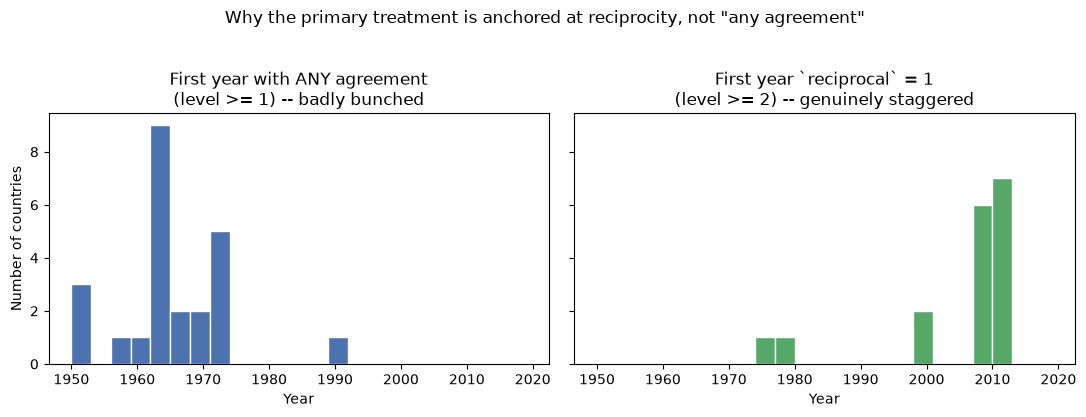

'Any agreement': 11 distinct years, 0 countries never reach it -- {1950: 3, 1957: 1, 1961: 1, 1962: 1, 1963: 1, 1964: 7, 1966: 2, 1968: 2, 1971: 1, 1972: 4, 1990: 1}
'Reciprocal':    7 distinct years, 7 countries never reach it by 2017


In [13]:
first_reciprocal = cy.loc[cy["reciprocal"] == 1].groupby("african_iso3")["year"].min()
first_any = cy.loc[cy["depth_score"] >= 1].groupby("african_iso3")["year"].min()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
bins = range(1950, 2020, 3)

axes[0].hist(first_any.to_numpy(), bins=bins, color="#4C72B0", edgecolor="white")
axes[0].set_title("First year with ANY agreement\n(level >= 1) -- badly bunched")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Number of countries")

axes[1].hist(first_reciprocal.to_numpy(), bins=bins, color="#55A868", edgecolor="white")
axes[1].set_title("First year `reciprocal` = 1\n(level >= 2) -- genuinely staggered")
axes[1].set_xlabel("Year")

fig.suptitle("Why the primary treatment is anchored at reciprocity, not \"any agreement\"", y=1.03)
fig.tight_layout()
plt.show()

print(f"'Any agreement': {first_any.nunique()} distinct years, "
      f"{(24 - first_any.shape[0])} countries never reach it -- {first_any.value_counts().sort_index().to_dict()}")
print(f"'Reciprocal':    {first_reciprocal.nunique()} distinct years, "
      f"{(24 - first_reciprocal.shape[0])} countries never reach it by 2017")

The left panel is nearly all of Africa becoming "treated" within a single
15-year window (1957–1972, driven by independence dates plus the immediate GSP
rollout) with almost no untreated countries left afterward. The right panel spreads
across five decades with real gaps and, as importantly, **7 of the 24 countries never
reach reciprocal status by 2017** — a genuine not-yet/never-treated comparison group
for a staggered-DiD design. This is the concrete confirmation of the design choice
argued for in §6.2 of the methodology document.

## 10. Save the cleaned panels

In [14]:
country_year_cols = [
    "african_iso3", "year", "country_exists", "depth_score", "agreement_type",
    "reciprocal", "fta_or_deeper", "nonreciprocal_only",
    "n_northern_reporting", "n_northern_with_agreement",
]
country_year = cy[country_year_cols].rename(columns={"african_iso3": "iso3"})

country_year_path = OUT_DIR / "baier_bergstrand_africa_northern_country_year.csv"
bilateral_path = OUT_DIR / "baier_bergstrand_africa_northern_bilateral.csv"

country_year.to_csv(country_year_path, index=False)
bilateral.to_csv(bilateral_path, index=False)

print(f"Saved {len(country_year):,} rows -> {country_year_path}")
print(f"Saved {len(bilateral):,} rows  -> {bilateral_path}")
country_year.head()

Saved 1,632 rows -> ..\data\processed\baier_bergstrand_africa_northern_country_year.csv
Saved 58,752 rows  -> ..\data\processed\baier_bergstrand_africa_northern_bilateral.csv


,iso3,year,country_exists,depth_score,agreement_type,reciprocal,fta_or_deeper,nonreciprocal_only,n_northern_reporting,n_northern_with_agreement
0,AGO,1950,True,0.0,0_none,0.0,0.0,0.0,28.0,0.0
1,AGO,1951,True,0.0,0_none,0.0,0.0,0.0,28.0,0.0
2,AGO,1952,True,0.0,0_none,0.0,0.0,0.0,28.0,0.0
3,AGO,1953,True,0.0,0_none,0.0,0.0,0.0,28.0,0.0
4,AGO,1954,True,0.0,0_none,0.0,0.0,0.0,28.0,0.0


## 11. Limitations and next steps

- **The `NR-PTA+` (GSP+) sub-code.** Baier–Bergstrand's raw scale includes a `1.1`
  sub-level for GSP+ alongside integer `1`. `pd.to_numeric` reads this as `1.1`, and
  `depth_score.eq(1)` in `nonreciprocal_only` would miss it; `depth_score >= 2` in
  `reciprocal` correctly still excludes it either way. If GSP+ needs to be
  distinguished from plain GSP later (§6.2 flags this as a possible finer cut within
  level 1), round `depth_score` down with `np.floor` before building `agreement_type`
  rather than truncating via `int()` as done above, and check the `0_none` /
  `1_nonreciprocal` boundary is unaffected.
- **The ~1.4% of country-pair/year cells** the authors could not fully verify (per
  `data/baier-bergstrand/README.md`) default to "no agreement" in the raw data with
  no separate flag column identifying which cells these are — inherited here as-is;
  not separately identifiable or excludable from this file alone.
- **Trade- or GDP-weighted exposure** (§6.2, step 5) is not built here — it needs
  bilateral trade flows (CEPII BACI or UN Comtrade) as an additional input.
- **Next notebook**: merge `country_year` with the GGDC sectoral productivity panel
  (`Global-Productivity-Sectoral-Database.dta`) on `iso3`/country and `year` to build
  the country–sector–year analysis panel described in §6.2–§6.3, then run the
  McMillan–Rodrik decomposition.